## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [2]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_y1985.1y_gridT.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979.nc'

# NEMO full grid coords
filepath_domain_cfg = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Set the filepaths 
# The target grid mask 
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
# The target grid geometry
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
folder_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 
filepath_nn_output = folder_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = False
nemo_version = '5'

# Looking at the T/S evolution in first year of simulation??

In [3]:
import glob
filepaths = glob.glob('/bettik/ockendeh/NEMO_simulations/test_data/files_to_copy/*.nc')
filepaths = sorted(filepaths)
#filepaths

In [4]:
# A function to load so and thetao for each input file
def func_data_load(filepath_nemo_output):
    gridT_varofint = xr.open_dataset(filepath_nemo_output)
    #print('You have loaded T and S:', filepath_nemo_output)
    # And cut out variables which are not needed
    gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop_vars('time_counter').drop_vars('time_centered')
    # Crop out most of the world and just save Antarctica 
    # Specify the coordinates needed
    min_lat = -52.2
    y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
    #print('Cropped to Antarctica only')
    # Take this slice 
    #gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))[['thetao','so', 'area', 'bathy', 'isf_draft']]
    gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))
    gridT2 = normalise_variable_names(gridT2)
    gridT2 = gridT2[['thetao', 'so']]#, 'area']]
    # Close the original dataset
    so = gridT2.so
    thetao = gridT2.thetao
    #print('Minimum salinity is:', np.nanmin(so.values))
    #print('Maximum salinity is:', np.nanmax(so.values))
    #ax.scatter(i, np.nanmin(so.values), c = 'red')
    #ax.scatter(i, np.nanmax(so.values), c = 'green')
    return so, thetao

## **Creating figures**

In [5]:
##

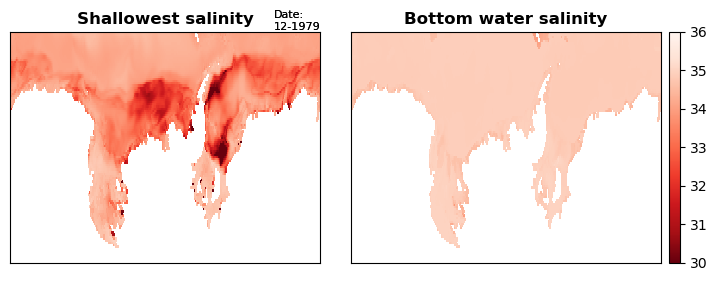

In [6]:
# An example figure
jj = 11
so, thetao = func_data_load(filepaths[jj])

fig, ax = plt.subplots(1,2, figsize = (10, 3))
fig.subplots_adjust(wspace=0.1)
im = [[],[]]
im[0] = ax[0].pcolor(so.bfill("deptht").isel(deptht = 0), cmap = 'Reds_r')
im[0].set_array(so.bfill("deptht").isel(deptht = 0))
im[1] = ax[1].pcolor(so.ffill("deptht").isel(deptht=-1), cmap = 'Reds_r')
im[1].set_array(so.ffill("deptht").isel(deptht = -1))
labels = 'Shallowest salinity', 'Bottom water salinity'
for i in range(2):
    if i == 1:
        plt.colorbar(im[i], ax = ax, pad = 0.01)
    im[i].set_clim(30,36)
    #im[i].set_clim(-2,10)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(labels[i], fontsize = 12, fontweight = 'bold')
    year = filepaths[jj].split('gridT_')[1].split('-')[0][0:4]
    month = filepaths[jj].split('gridT_')[1].split('-')[0][4:]
    ax[0].annotate('Date:\n{}-{}'.format(month, year), xy = (0,0), xytext = (0.85, 1.01), fontsize = 8, xycoords = 'axes fraction')
    #fig.savefig('FIGURES/salinity_{}.jpg'.format(jj), bbox_inches = 'tight', dpi = 200)

In [7]:
# To produce 5 years of figures for making into a gif 
plot_for_gif = False
if plot_for_gif == True:
    for jj in range(len(filepaths)):
        so, thetao = func_data_load(filepaths[jj])
        fig, ax = plt.subplots(1,2, figsize = (10, 3))
        fig.subplots_adjust(wspace=0.1)
        im = [[],[]]
        im[0] = ax[0].pcolor(so.bfill("deptht").isel(deptht = 0), cmap = 'Reds_r')
        im[0].set_array(so.bfill("deptht").isel(deptht = 0))
        im[1] = ax[1].pcolor(so.ffill("deptht").isel(deptht=-1), cmap = 'Reds_r')
        im[1].set_array(so.ffill("deptht").isel(deptht = -1))
        labels = 'Shallowest salinity', 'Bottom water salinity'
        for i in range(2):
            if i == 1:
                plt.colorbar(im[i], ax = ax, pad = 0.01)
            im[i].set_clim(10,36)
            #im[i].set_clim(-2,10)
            ax[i].set_xticks([])
            ax[i].set_yticks([])
            ax[i].set_title(labels[i], fontsize = 12, fontweight = 'bold')
        year = filepaths[jj].split('gridT_')[1].split('-')[0][0:4]
        month = filepaths[jj].split('gridT_')[1].split('-')[0][4:]
        ax[0].annotate('Date:\n{}-{}'.format(month, year), xy = (0,0), xytext = (0.85, 1.01), fontsize = 8, xycoords = 'axes fraction')
        fig.savefig('FIGURES/salinities/salinity_{}.jpg'.format(jj), bbox_inches = 'tight', dpi = 200)
        plt.close()

In [8]:
# To plot the gif
plot_gif = False
if plot_gif == True:
    from PIL import Image
    frames = [Image.open(f'FIGURES/salinities/salinity_{jj}.jpg') for jj in range(len(filepaths))]
    frames[0].save(
        'FIGURES/salinities10.gif',
        save_all=True,
        append_images=frames[1:],
        duration=1000,  # milliseconds per frame
        loop=0)

## Salinity and temperature profiles

In [9]:
# Load in the mask for the ocean region 
bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
mask_nocavs = bmach_masks.mask_nocavs.values
bmach_masks.close()

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
# Rename the dimensions of basins merged to be x and y 
if 'y_grid_T' in basins_merged.dims:
    basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# The basins mask for the NEMO 025 grid  
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')
basin_nos = np.unique(basins_NEMO)

# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where((mask_nocavs == 1))
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)

You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [10]:
filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc'
verbose = 2
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/test_data/files_to_copy/eORCA1.L75-TOTO_1m_gridT_197901-197901.nc'

In [11]:
# Load in the TS grid 


### Create a list of the cells where it is okay to extract ocean profiles 

In [12]:
def calculate_TS_profiles(filepath_nemo_output):
    gridT2 = load_TSmelt_normal(filepath_nemo_output);

    # For each basin in basin_nos, create a mask of the ocean profiles to extract 
    profiles_all = []
    i_no_value = []
    basins_all_temp = np.zeros_like(mask_nocavs)
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        # Stack cavity points to query KDTree
        cav_points = np.column_stack((x_cavs, y_cavs))
        dist, idx = tree.query(cav_points)
        # Same dimensions as the mask of the not cavities
        ocean_edge_basin = np.zeros_like(mask_nocavs)
        # And fill the cells found with the kd-tree
        # Should allow cells which are adjacent or as close to adjacent as possible
        if len(idx) == 1:
            for k in range(len(idx)):
                ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
        elif len(idx) != 0:
            idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
            for k in range(len(idxn)):
                ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
        else:
            # Calculate which basins don't have profiles
            i_no_value.append(int(i))
        ### This is only needed if you want to look at which ocean cells will recieve melt from many basins   
        basins_all_temp = basins_all_temp + ocean_edge_basin
        
        # Use the mask to extract the relevant profiles 
        masked_depth = gridT2.where(ocean_edge_basin == 1)
        profiles = masked_depth.stack(points=("x", "y"))
        profiles = profiles.dropna(dim="points", how="all")
        #profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
        # Fill the nan values in the profile
        profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
        # Add a coordinate for kk
        profile_kk = profile_kk.expand_dims(kk =[int(i)])
        #profile_kk = profile_kk.expand_dims(kk_m1 =[int(i)-1])
        profiles_all.append(profile_kk)
        if verbose == 1:
            print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')
    # Concatenate the profiles along the new dimension
    all_profiles = xr.concat(profiles_all, dim="kk")
    print('There are {} basins with no ocean profiles : {}'.format(len(i_no_value), i_no_value))

    return all_profiles

In [130]:
filepaths_nemo = glob.glob('/bettik/ockendeh/NEMO_simulations/test_data/gridT_*.nc')
filepaths_nemo = glob.glob('/bettik/ockendeh/NEMO_simulations/files_copy/*gridT*.nc')
filepaths_nemo = sorted(filepaths_nemo)
filepaths_nemo

['/bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1979-1979.nc',
 '/bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1980-1980.nc',
 '/bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1981-1981.nc',
 '/bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1982-1982.nc',
 '/bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1983-1983.nc']

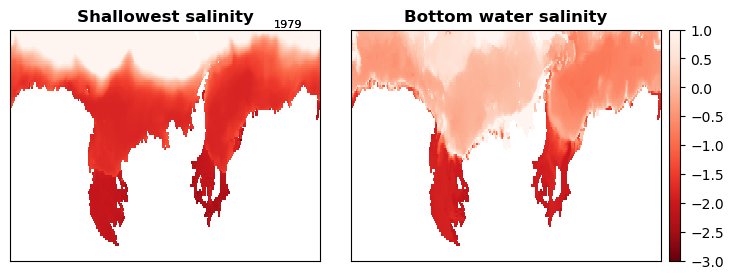

In [131]:
# An example figure
so, thetao = func_data_load(filepaths_nemo[0])

fig, ax = plt.subplots(1,2, figsize = (10, 3))
fig.subplots_adjust(wspace=0.1)
im = [[],[]]
im[0] = ax[0].pcolor(thetao.bfill("deptht").isel(deptht = 0), cmap = 'Reds_r')
im[0].set_array(thetao.bfill("deptht").isel(deptht = 0))
im[1] = ax[1].pcolor(thetao.ffill("deptht").isel(deptht=-1), cmap = 'Reds_r')
im[1].set_array(thetao.ffill("deptht").isel(deptht = -1))
labels = 'Shallowest salinity', 'Bottom water salinity'
for i in range(2):
    if i == 0:
        plt.colorbar(im[i], ax = ax, pad = 0.01)
    #im[i].set_clim(15,36)
    im[i].set_clim(-3,1)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(labels[i], fontsize = 12, fontweight = 'bold')
    ax[0].annotate('1979', xy = (0,0), xytext = (0.85, 1.01), fontsize = 8, xycoords = 'axes fraction')
    #fig.savefig('FIGURES/salinity_{}.jpg'.format(jj), bbox_inches = 'tight', dpi = 200)

You have loaded T and S: /bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1983-1983.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1982-1982.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1981-1981.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1980-1980.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1979-1979.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []


/tmp/ipykernel_2062126/2676294527.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc = (0,1.02), ncols = 5)


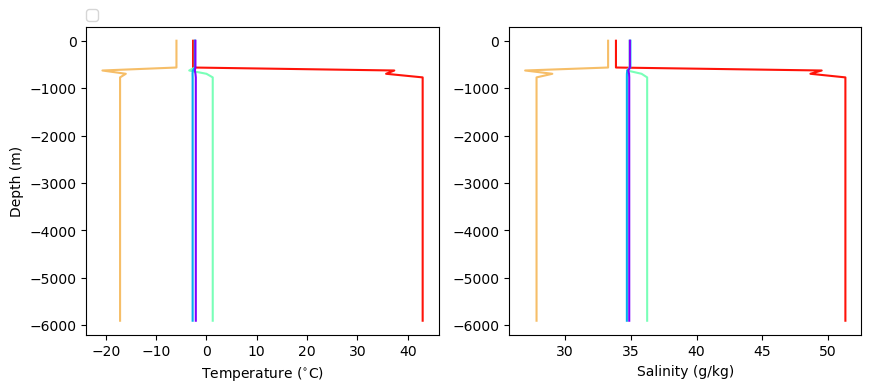

In [132]:
fig, ax = plt.subplots(1,2, figsize = (10,4))
#for i in range(len(filepaths_nemo)):
for i in (4,3,2,1,0):
    all_profiles = calculate_TS_profiles(filepaths_nemo[i])
    kk = 55.0
    profile = all_profiles.sel(kk=kk)
    if kk == 1:
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.rainbow(i/4.1), alpha = 1, label = '{}'.format(1979+i))
    else:    
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.rainbow(i/4.1), alpha = 1)
    ax[1].plot(profile.so, -profile.deptht, c = plt.cm.rainbow(i/4.1), alpha = 1)
ax[0].legend(loc = (0,1.02), ncols = 5)
ax[0].set_ylabel('Depth (m)');
#ax[1].set_ylabel('Depth (m)')
ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
ax[1].set_xlabel('Salinity (g/kg)');

fig.savefig('T_S_profiles_5yr.jpg', dpi = 200, bbox_inches = 'tight')

You have loaded T and S: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1983.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1982.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1981.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1980.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []


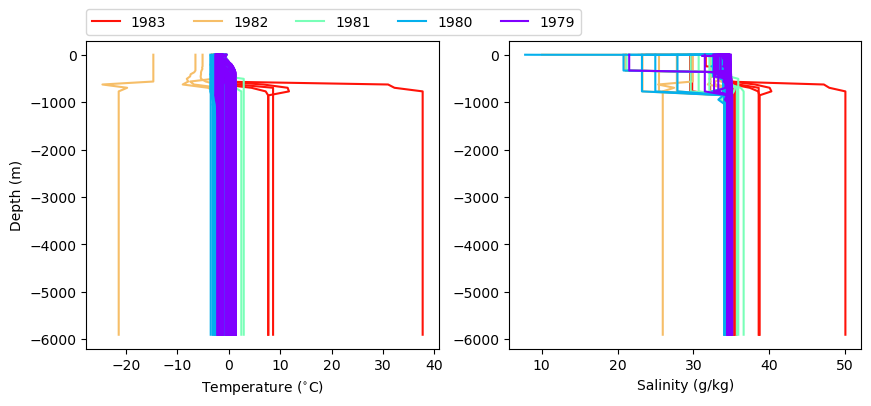

In [16]:
fig, ax = plt.subplots(1,2, figsize = (10,4))
#for i in range(len(filepaths_nemo)):
for i in (4,3,2,1,0):
    all_profiles = calculate_TS_profiles(filepaths_nemo[i])
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        if kk == 1:
            ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.rainbow(i/4.1), alpha = 1, label = '{}'.format(1979+i))
        else:    
            ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.rainbow(i/4.1), alpha = 1)
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.rainbow(i/4.1), alpha = 1)
ax[0].legend(loc = (0,1.02), ncols = 5)
ax[0].set_ylabel('Depth (m)');
#ax[1].set_ylabel('Depth (m)')
ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
ax[1].set_xlabel('Salinity (g/kg)');

fig.savefig('T_S_profiles_5yr.jpg', dpi = 200, bbox_inches = 'tight')

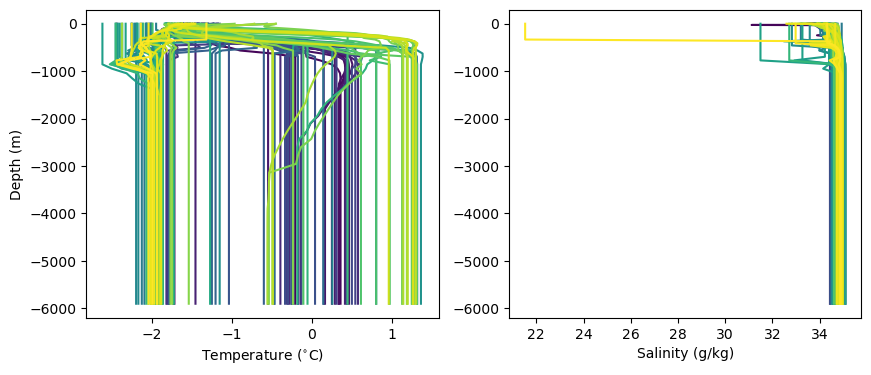

In [17]:
plot_profile = True
if plot_profile == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
    ax[0].set_ylabel('Depth (m)');
    #ax[1].set_ylabel('Depth (m)')
    ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
    ax[1].set_xlabel('Salinity (g/kg)');
fig.savefig('profile.jpg', dpi = 200, bbox_inches = 'tight')

In [133]:
def propagate_temp(all_profiles):
    # Extract the relevant values of temperature and salinity 
    temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
    temp_xy = temp_xy.reset_coords(drop=True)
    sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
    sals_xy = sals_xy.reset_coords(drop=True)
    
    # Calculate mean and standard deviation by region
    # Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
    meanT_by_region = temp_xy.groupby(basins_merged).mean()
    stdT_by_region  = temp_xy.groupby(basins_merged).std()
    meanS_by_region = sals_xy.groupby(basins_merged).mean()
    stdS_by_region  = sals_xy.groupby(basins_merged).std()
    # and send back to the original grid 
    mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
    std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
    mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
    std_S = stdS_by_region.sel(basins_NEMO = basins_merged)
    # Reset the coordinates
    mean_T = mean_T.reset_coords(drop=True)
    mean_S = mean_S.reset_coords(drop=True)
    std_T = std_T.reset_coords(drop=True)
    std_S = std_S.reset_coords(drop=True)
    return temp_xy, sals_xy, mean_T, mean_S, std_T, std_S

You have loaded T and S: /bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1983-1983.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []


/tmp/ipykernel_2062126/349708331.py:17: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)


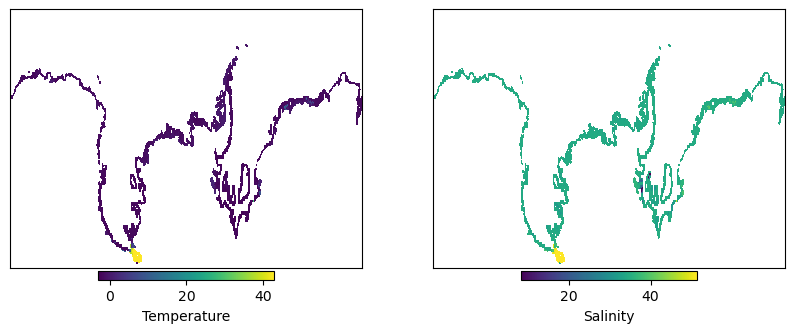

In [134]:
all_profiles = calculate_TS_profiles(filepaths_nemo[4])
temp_xy, sals_xy, mean_T, mean_S, std_T, std_S = propagate_temp(all_profiles)

plot_figure = True
if plot_figure == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    #closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    closed_cavs = masks.closed_cavities_nan#.rename({"y_grid_T": "y", "x_grid_T": "x"})
    im = [[],[]]
    # Note that using pcolor rather than pcolormesh leads to the error
    im[0] = ax[0].pcolor(temp_xy*closed_cavs)
    im[1] = ax[1].pcolor(sals_xy*closed_cavs)
    labels = 'Temperature', 'Salinity'
    for i in range(2):
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)
        cbar.set_label(labels[i])
fig.savefig('Propagated.jpg',dpi= 200, bbox_inches = 'tight')

In [135]:
# Create the input dataset for the neural network to be applied to
def create_nn_input(temp_xy, sals_xy, mean_T, mean_S, std_T, std_S):
    ds = geoms.rename({"areas": "area",
                       "isf_draft": "corrected_isdraft",
                       "slope_isdraft_lon": "slope_is_lon",
                       "slope_isdraft_lat": "slope_is_lat",
                       "slope_bathy_lon": "slope_ba_lon",
                       "slope_bathy_lat": "slope_ba_lat",})
    ds = ds.assign(temperature_prop = temp_xy,
                      mean_T           = mean_T,
                      std_T            = std_T,
                      salinity_prop    = sals_xy,
                      mean_S           = mean_S,
                      std_S            = std_S,
                      basins_NEMO      = basins_merged,)
    ds.attrs["description"] = "Neural network input variables"
    # Rename variables in closed cavity mask 
    if 'y_grid_T' in basins_merged.dims:
        closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    else:
        closed_cavs = masks.closed_cavities_nan
    # Select only the points in the closed cavity regions
    stacked = ds.where(closed_cavs == 1).stack(points=("x", "y")).dropna("points", how = "all")
    # and convert to a pandas dataframe
    selected = stacked.to_dataframe().reset_index().drop(columns=["x", "y"])
    # Remove nan values (although still unclear why there are nan values)
    selected = selected[~np.isnan(selected.temperature_prop)]
    return selected 

In [136]:
def apply_10nns(exp_name, this_collection, clean_df, path_model, path_norm_metrics, 
                       mod_size = 'small', 
                         TS_opt = 'extrap', 
                    norm_method = 'std', 
                        verbose = 0, 
                    annual_only = False, 
               apply_collection = None, 
                       annual_f = ''):
    # Load in the normalisation metrics 
    norm_metrics = load_normalisation_metrics(this_collection, path_norm_metrics, norm_method = 'std', verbose = 0)
    # Extract the values that you might want from the clean dataframe
    df_pred = pd.DataFrame({'lat'   : clean_df.lat, 
                            'lon'   : clean_df.lon,
                            'basin' : clean_df.basins_NEMO,
                            'area'  : clean_df.area, 
                            'fraction' : clean_df.fraction})
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    start_time = time.time()
    for i in range(len(seed_nb_array)):
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
    
        model = load_model_nn(exp_name, this_collection, path_model, seed_nb_array[i], \
                                  mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                                  verbose = verbose, annual_f = annual_f) 
        df_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = verbose)
        end_time = time.time()
        print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.1f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_pred['mean_melt'] = np.mean(df_pred[list_melt_seeds], axis = 1).values
    if verbose == 1:
        print('Maximum melt rate: {:.5f} '.format(np.min(df_pred.mean_melt.values)))
        print('Minimum melt rate: {:.5f} '.format(np.max(df_pred.mean_melt.values)))
        print('Mean melt rate: {:.5f} '.format(np.mean(df_pred.mean_melt.values)))
    # And the standard deviation 
    df_pred['std_melt'] = np.std(df_pred[list_melt_seeds], axis = 1).values
    #df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * (60*60*24*365.25)/917
    df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * df_pred.area * df_pred.fraction * 31536000 * 1/1e12
    # Save just the ensemble mean/std
    #df_save = df_pred.copy()[['lat','lon', 'basin', 'area', 'mean_melt', 'std_melt', 'melt_Gt']]
    # Save just the melt by basin/
    melt = df_pred
    melt['x'], melt['y'] = transformer.transform(melt.lat, melt.lon)
    melt_by_basin = df_pred.groupby('basin', as_index = False).sum()[['basin','melt_Gt']]
    #lat_lon_by_basin = df_pred.groupby('basin', as_index = False).mean()[['lat','lon']]
    return melt, melt_by_basin

In [143]:
all_profiles = calculate_TS_profiles(filepaths_nemo[1])
temp_xy, sals_xy, mean_T, mean_S, std_T, std_S = propagate_temp(all_profiles)
selected = create_nn_input(temp_xy, sals_xy, mean_T, mean_S, std_T, std_S)
melt, melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)

You have loaded T and S: /bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_gridT_1980-1980.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []


In [144]:
melt_rate_figures = False
if melt_rate_figures == True:
    for jj in range(len(filepaths_nemo)):
        all_profiles = calculate_TS_profiles(filepaths_nemo[jj])
        temp_xy, sals_xy, mean_T, mean_S, std_T, std_S = propagate_temp(all_profiles)
        selected = create_nn_input(temp_xy, sals_xy, mean_T, mean_S, std_T, std_S)
        melt, melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)
        print(jj, np.sum(melt_by_basin.melt_Gt), np.sum(melt.melt_Gt))
        
        fig, axs = plt.subplots(1,2, figsize = (6,5))
        axs[0].set_position([0,0,1,1])
        axs[1].set_position([0.2,0.2,0.3,0.02])
        ax = axs[0]
        ax.axis('off');
        im = ax.scatter(melt.x, melt.y, c = -melt.melt_Gt, s = 0.01, cmap = 'coolwarm')
        print(np.min(melt.melt_Gt), -np.min(melt.melt_Gt))
        im.set_clim(-5,5)
        cbar = plt.colorbar(im, shrink = 0.5, cax = axs[1], orientation = 'horizontal')
        cbar.set_label('Melt (Gt/yr)')
        ax.annotate('Melting', xy = (0,0), xytext = (0.43, 0.23), xycoords = 'axes fraction', fontsize = 8, color = 'crimson')
        ax.annotate('Re-freezing', xy = (0,0), xytext = (0.2, 0.23), xycoords = 'axes fraction', fontsize = 8, color = 'royalblue')
        #ax.set_xlim(-2e6,-1e6)
        #ax.set_ylim(-1e6,0e6)
        ax.annotate(jj, xy = (0,0), xytext = (0.9,0.9), xycoords = 'axes fraction')
    
        fig.savefig('FIGURES/Melt_all_{}.jpg'.format(jj), dpi = 200, bbox_inches = 'tight')
        plt.close()
else:
    print('You have chosen not to plot these figures')

You have chosen not to plot these figures


In [145]:
# To plot the gif
plot_gif = False
if plot_gif == True:
    from PIL import Image
    frames = [Image.open(f'FIGURES/Melt_all_{jj}.jpg') for jj in range(len(filepaths_nemo))]
    frames[0].save(
        'FIGURES/Melt_all.gif',
        save_all=True,
        append_images=frames[1:],
        duration=2000,  # milliseconds per frame
        loop=0)

-5.973872933852804 5.973872933852804


Text(0.2, 0.23, 'Re-freezing')

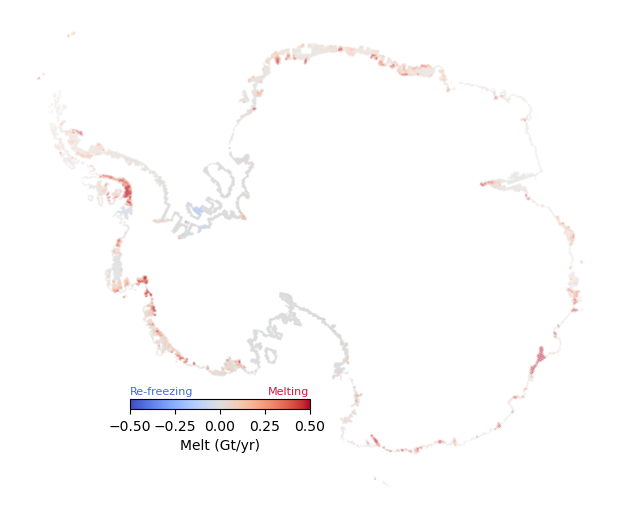

In [146]:
fig, axs = plt.subplots(1,2, figsize = (6,5))
axs[0].set_position([0,0,1,1])
axs[1].set_position([0.2,0.2,0.3,0.02])
ax = axs[0]
ax.axis('off');
im = ax.scatter(melt.x, melt.y, c = -melt.melt_Gt, s = 0.01, cmap = 'coolwarm')
print(np.min(melt.melt_Gt), -np.min(melt.melt_Gt))
im.set_clim(-0.5,0.5)
cbar = plt.colorbar(im, shrink = 0.5, cax = axs[1], orientation = 'horizontal')
cbar.set_label('Melt (Gt/yr)')
ax.annotate('Melting', xy = (0,0), xytext = (0.43, 0.23), xycoords = 'axes fraction', fontsize = 8, color = 'crimson')
ax.annotate('Re-freezing', xy = (0,0), xytext = (0.2, 0.23), xycoords = 'axes fraction', fontsize = 8, color = 'royalblue')
#ax.set_xlim(-2e6,-1e6)
#ax.set_ylim(-1e6,0e6)

In [147]:
## A side quest to have melt per basin with lat/lon coords 

masked_lat = masks.lat.where(masks.closed_cavities == 1)
masked_lon = masks.lon.where(masks.closed_cavities == 1)

mean_lat = masked_lat.groupby(masks.basins_NEMO).mean()
mean_lon = masked_lon.groupby(masks.basins_NEMO).mean()

mean_bybasin = xr.Dataset({
    "mean_lat": mean_lat,
    "mean_lon": mean_lon
})
mean_bybasin = mean_bybasin.rename({'basins_NEMO':'basin'})

df_coords = mean_bybasin.to_dataframe().reset_index()
df_merged = df_coords.merge(melt_by_basin, on="basin")
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
df_merged['x'], df_merged['y'] = transformer.transform(df_merged.mean_lat, df_merged.mean_lon)

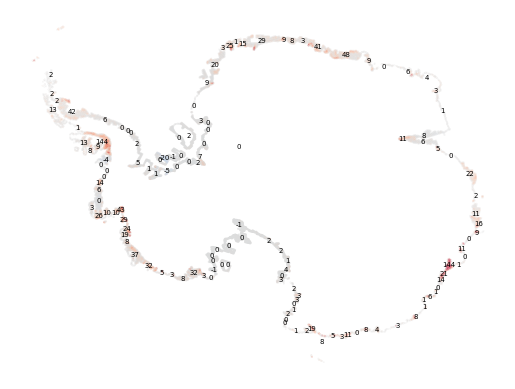

In [148]:
fig, ax = plt.subplots(1,1)
im = ax.scatter(melt.x, melt.y, c = -melt.melt_Gt, s = 0.01, cmap = 'coolwarm')
im.set_clim(-1,1)
idx = np.argsort(df_merged.melt_Gt)
for jj in range(len(df_merged.basin)):
#    if jj in idx[0:5]:
#    if np.abs(df_merged.melt_Gt[jj]) > 50:
    ax.annotate('{}'.format(-int(df_merged.melt_Gt[jj])), xy = (0,0), \
            xytext = (df_merged.x[jj], df_merged.y[jj]), xycoords = 'data', \
                fontsize = 5, ha = 'center', va = 'center')
ax.axis('off');

In [28]:
df_merged

,basin,mean_lat,mean_lon,melt_Gt,x,y
0,0.0,-73.422661,-61.068893,-1.051633,-1.587031e+06,8.772129e+05
1,1.0,-82.519600,-55.252537,-7.517568,-6.687372e+05,4.638757e+05
2,2.0,-75.133072,-21.193455,-11.185993,-5.871365e+05,1.514241e+06
3,3.0,-73.136208,-15.553082,-36.684747,-4.947287e+05,1.777538e+06
4,4.0,-71.091789,-8.562792,-27.961650,-3.085842e+05,2.049418e+06
...,...,...,...,...,...,...
129,129.0,-79.311996,-159.331009,-0.672249,-4.110392e+05,-1.089567e+06
130,130.0,-80.691742,-61.655125,-0.672550,-8.919919e+05,4.811897e+05
131,131.0,-80.061447,-64.550873,0.048954,-9.774207e+05,4.651409e+05
132,132.0,-78.873459,-70.167305,-1.904812,-1.140664e+06,4.113998e+05


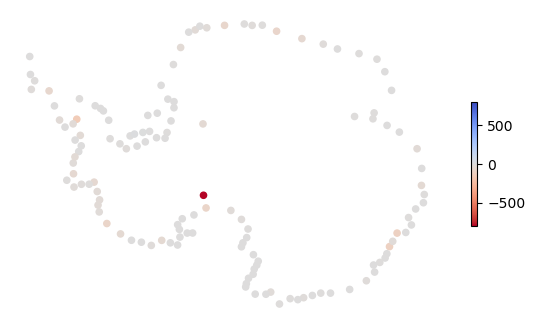

In [29]:
fig, ax = plt.subplots(1,1, figsize = (7,4))
im = [[],[]]
im[0] = plt.scatter(df_merged.x, df_merged.y, s = 20, c = df_merged.melt_Gt, \
                    cmap = 'coolwarm_r', alpha = 1)
#im[1] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(df_merged.melt_Gt), cmap = 'Blues')
ax.axis('off');
plt.colorbar(im[0], shrink = 0.4)
#plt.colorbar(im[1], shrink = 0.4)
im[0].set_clim(-800,800)
#im[1].set_clim(-1.1,2.1)

/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


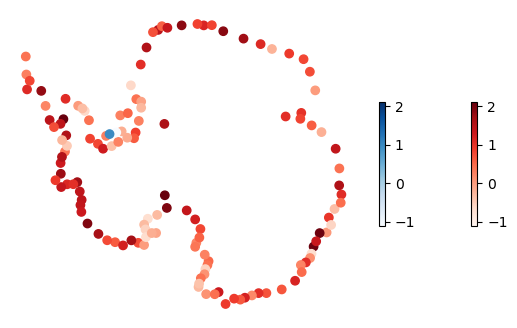

In [30]:
fig, ax = plt.subplots(1,1, figsize = (7,4))
im = [[],[]]
im[0] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(-df_merged.melt_Gt), cmap = 'Reds')
im[1] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(df_merged.melt_Gt), cmap = 'Blues')
ax.axis('off');
plt.colorbar(im[0], shrink = 0.4)
plt.colorbar(im[1], shrink = 0.4)
im[0].set_clim(-1.1,2.1)
im[1].set_clim(-1.1,2.1)

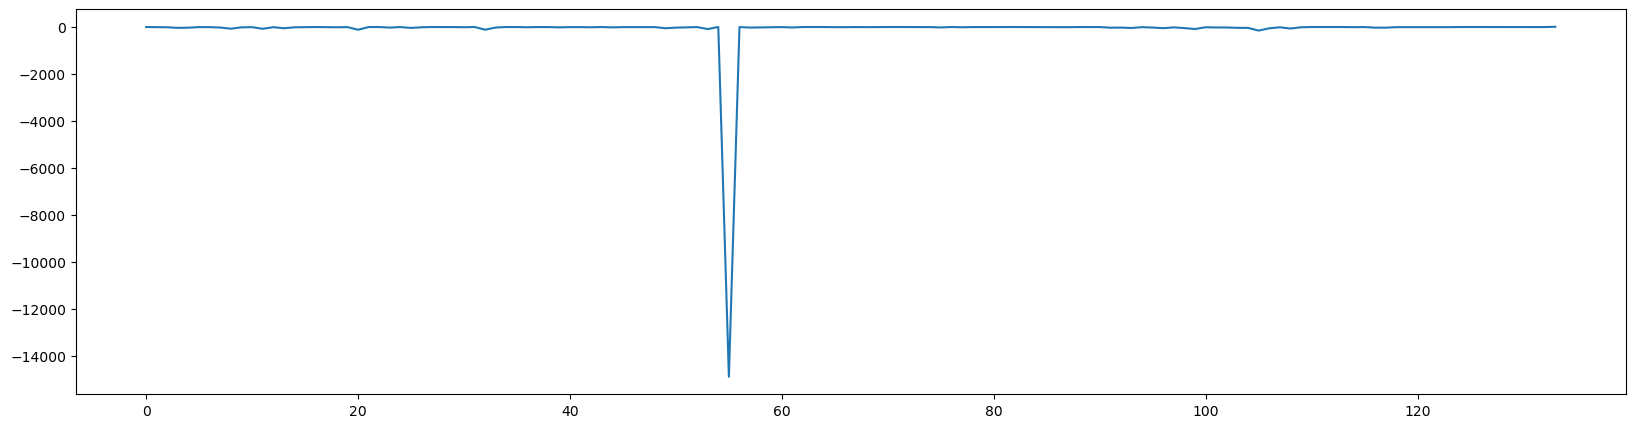

In [31]:
fig, ax = plt.subplots(1,1, figsize = (20,5))
plt.plot(melt_by_basin.basin, melt_by_basin.melt_Gt)
#plt.xlim(98,100)

In [32]:
areas = load_area(filepath_nemo_output)
melt_all = np.zeros_like(mask_nocavs)
melt_b = np.zeros_like(mask_nocavs)
melt_t = np.zeros_like(mask_nocavs)
print('Putting melt back onto the ocean grid')
for kk in range(len(melt_by_basin.basin)):
    i = melt_by_basin.basin[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Calculate the top and bottom depths to inject the melt 
    # Currently using means, but might be better to use a min/max? ideally at cells touching the ocean 
    melt_b_basin = np.mean(geoms.bathymetry.values[mask_basin_cavs == 1])
    melt_t_basin = np.mean(geoms.isf_draft.values[mask_basin_cavs == 1])
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    # Redistribute the melt over the relevant cells
    # Number of pixels?
    #pixels = np.sum(ocean_edge_basin)
    # Total area covered 
    ocean_area = np.sum(areas * ocean_edge_basin).data
    # Melt per pixel?? 
    melt_per_pixel = melt_by_basin.melt_Gt[kk] * (10e12/(60*60*24*365.5)) /ocean_area
    ocean_melt = ocean_edge_basin * melt_per_pixel
    # Apply top and bottom over the relevant cells
    ocean_melt_b = ocean_edge_basin * melt_b_basin
    ocean_melt_t = ocean_edge_basin * melt_t_basin
    # Sum up the melt over all the basins
    melt_all = melt_all + ocean_melt
    melt_b = melt_b + ocean_melt_b
    melt_t = melt_t + ocean_melt_t
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')

You have loaded: /bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc
Cropped to Antarctica only
Returning area
Putting melt back onto the ocean grid


In [33]:
# Expanding the grid back to the NEMO eORCA1 grid
# gridT_varofint = xr.open_dataset('/ccc/work/cont003/gen6035/ockendeh/NEMO/eORCA1.L75/eORCA1.L75-I/eORCA1.4.3_CavsForNN_domain_cfg.nc')[['x','y']]
gridT_varofint = xr.open_dataset(filepath_nemo_output)[['x','y']]
min_lat = -52.2
y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
full_t   = expand_to_full_grid(melt_t,    y_trim, gridT_varofint)
full_b   = expand_to_full_grid(melt_b,    y_trim, gridT_varofint)
full_all = expand_to_full_grid(melt_all,  y_trim, gridT_varofint)

if nemo_version == '5':
    # In NEMO 5 the melt convention has changed
    # Melting is now positive and refreezing is now negative 
    print('New NEMO version (v{}), melt is positive'.format(nemo_version))
    full_all = full_all * -1 
else:
    # In NEMO 4 the melt convention is the same as in Pierre's simulations
    print('Old NEMO version (v{}), melt is negative'.format(nemo_version))
    full_all = full_all 

New NEMO version (v5), melt is positive


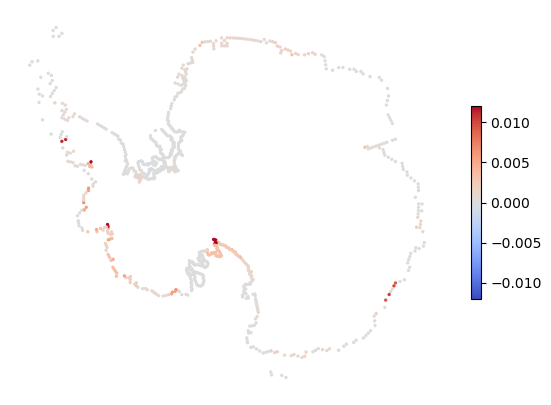

In [34]:
full_all2 = full_all.fillna(0)
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
#df_merged['x'], df_merged['y'] = transformer.transform(df_merged.mean_lat, df_merged.mean_lon)
full_x, full_y = transformer.transform(full_all2.nav_lat.values[full_all2.values != 0], full_all2.nav_lon.values[full_all2.values != 0])
full_m = full_all2.values[full_all2.values != 0]

fig, ax = plt.subplots(1,1, figsize = (7,5))
im = [[],[]]
im[0] = plt.scatter(full_x, full_y, s = 2, c = full_m, cmap = 'coolwarm')
#im[1] = plt.scatter(full_x, full_y, c = np.log10(-full_m), cmap = 'Blues', s = 1)
i#m.set_clim(-0.002,0.002)

cbar = plt.colorbar(im[0], shrink = 0.5)
im[0].set_clim(-0.012,0.012)
    #cbar.set_ticks((-5,-4,-3,-2))
    #cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
ax.axis('off');

/tmp/ipykernel_2062126/3759204771.py:9: RuntimeWarning: invalid value encountered in log10
  im[0] = plt.scatter(full_x, full_y, c = np.log10(full_m), cmap = 'Reds', s = 1)
/tmp/ipykernel_2062126/3759204771.py:10: RuntimeWarning: invalid value encountered in log10
  im[1] = plt.scatter(full_x, full_y, c = np.log10(-full_m), cmap = 'Blues', s = 1)


(np.float64(-2943106.5455497988),
 np.float64(2976965.1026553703),
 np.float64(-2693519.1989864265),
 np.float64(2595339.2915781313))

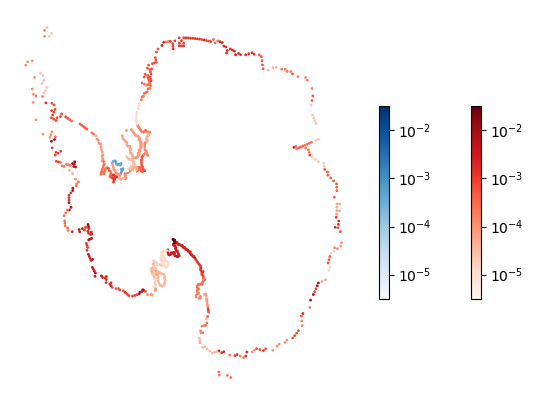

In [35]:
full_all2 = full_all.fillna(0)
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
#df_merged['x'], df_merged['y'] = transformer.transform(df_merged.mean_lat, df_merged.mean_lon)
full_x, full_y = transformer.transform(full_all2.nav_lat.values[full_all2.values != 0], full_all2.nav_lon.values[full_all2.values != 0])
full_m = full_all2.values[full_all2.values != 0]

fig, ax = plt.subplots(1,1, figsize = (7,5))
im = [[],[]]
im[0] = plt.scatter(full_x, full_y, c = np.log10(full_m), cmap = 'Reds', s = 1)
im[1] = plt.scatter(full_x, full_y, c = np.log10(-full_m), cmap = 'Blues', s = 1)
i#m.set_clim(-0.002,0.002)
for i in range(2):
    cbar = plt.colorbar(im[i], shrink = 0.5)
    im[i].set_clim(-5.5,-1.5)
    cbar.set_ticks((-5,-4,-3,-2))
    cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
ax.axis('off')

In [36]:
# Create a netcdf dataset for the temperature and salinity profiles 
output_melt = xr.Dataset(data_vars=dict(
                                melt      = (["y", "x"], full_all.data), 
                                melt_top  = (["y", "x"], full_t.data),
                                melt_base = (["y", "x"], full_b.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), full_all.nav_lon.data),
                               lat = (("y", "x"), full_all.nav_lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network output", 
                               simulation_run = simulation, 
                               year           = year_of_interest, 
                               history        = f"{time.ctime()}: Applied neural network"),
                        )     

output_melt = output_melt.fillna(0)
print('Nan values filled')

output_melt["melt"].attrs.update({"standard_name": "Sub-shelf melt for parameterised regions",
                                  "units": "kg m-2 s-1"})
output_melt["melt_top"].attrs.update({"standard_name": "Top level to inject melt",
                                     "units": "m"})
output_melt["melt_base"].attrs.update({"standard_name": "Bottom level to inject melt",
                                     "units": "m"})
output_melt["lat"].attrs.update({"standard_name": "Latitude",
                                 "units": "degrees_north"})
output_melt["lon"].attrs.update({"standard_name": "Longitude",
                                 "units": "degrees_east"})

# Export to netcdf 
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

filepath_this_nn_output = filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'
output_melt.to_netcdf(filepath_this_nn_output)
print('You have saved the nn output to:', filepath_this_nn_output)

Nan values filled
You have saved the nn output to: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_output_melt_DUM002_9999.ncnn_output_melt_DUM002_9999.nc


/tmp/ipykernel_2062126/3354854944.py:6: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
/tmp/ipykernel_2062126/3354854944.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_2062126/3354854944.py:11: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
/tmp/ipykernel_2062126/3354854944.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


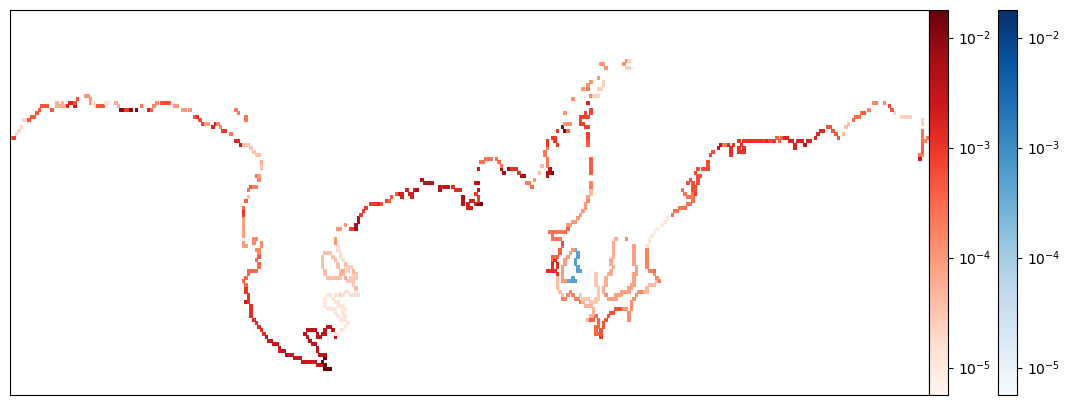

In [37]:
melt = xr.open_dataset(filepath_this_nn_output)# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')

In [38]:
melt_files = glob.glob('/bettik/ockendeh/NEMO_simulations/test_data/nn_output_melt_TOTO*.nc')
melt_files = sorted(melt_files)
melt_files

['/bettik/ockendeh/NEMO_simulations/test_data/nn_output_melt_TOTO_1979.nc',
 '/bettik/ockendeh/NEMO_simulations/test_data/nn_output_melt_TOTO_1980.nc',
 '/bettik/ockendeh/NEMO_simulations/test_data/nn_output_melt_TOTO_1981.nc',
 '/bettik/ockendeh/NEMO_simulations/test_data/nn_output_melt_TOTO_1982.nc',
 '/bettik/ockendeh/NEMO_simulations/test_data/nn_output_melt_TOTO_1983.nc']

In [39]:
np.nanmin(melt_all), np.nanmax(melt_all)

(np.float64(-0.0004943158722955591), np.float64(2.6181618693393642))

In [40]:
for jj in range(len(melt_files)):
    melt_file = xr.open_dataset(melt_files[jj])
    melt_all = melt_file.melt.values
    melt_all[melt_all == 0] = np.nan
    
    fig, ax = plt.subplots(1,1, figsize = (15,5))
    im = plt.pcolor(melt_all, cmap = 'coolwarm')
    im.set_array(melt_all)
    im.set_clim(-0.0026,0.0026)
    cbar = plt.colorbar(im, ax= ax, pad = 0.01)
    #cbar.set_ticks((-5,-4,-3,-2))
    #cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
    #im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
    #im.set_clim(-5.25,-1.75)
    #cbar = plt.colorbar(im, ax= ax, pad = 0)
    #cbar.set_ticks((-5,-4,-3,-2))
    #cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
    
    ax.set_xticks([]);
    ax.set_yticks([]);
    ax.set_ylim(0,110)

    ax.annotate(jj, xy = (0,0), xytext = (0.9, 1.01), xycoords = 'axes fraction')
    
    fig.savefig('FIGURES/Melt_{}.jpg'.format(jj), dpi = 200, bbox_inches = 'tight')
    plt.close()

In [41]:
# To plot the gif
plot_gif = True
if plot_gif == True:
    from PIL import Image
    frames = [Image.open(f'FIGURES/Melt_{jj}.jpg') for jj in range(len(melt_files))]
    frames[0].save(
        'FIGURES/melt_input.gif',
        save_all=True,
        append_images=frames[1:],
        duration=1000,  # milliseconds per frame
        loop=0)
print('Gif saved')

Gif saved


/tmp/ipykernel_2062126/351230665.py:6: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
/tmp/ipykernel_2062126/351230665.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_2062126/351230665.py:11: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
/tmp/ipykernel_2062126/351230665.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


(0.0, 110.0)

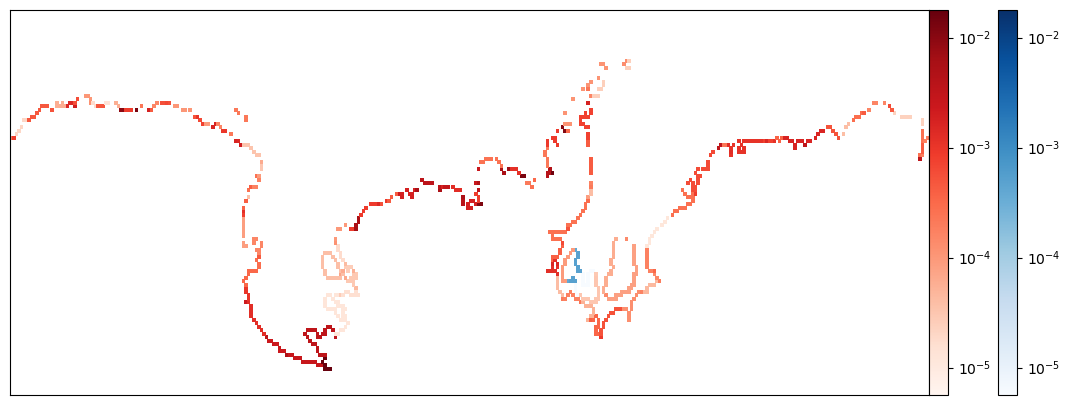

In [42]:
melt_file = xr.open_dataset(melt_files[4])
melt_all = melt_file.melt.values
melt_all[melt_all == 0] = np.nan

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
ax.set_ylim(0,110)


In [43]:
filepath_flx = '/bettik/ockendeh/NEMO_simulations/test_data/flxT_1979.nc'

In [44]:
flx = xr.open_dataset(filepath_flx)

In [45]:
flx

<xarray.Dataset> Size: 21MB
Dimensions:               (y: 331, x: 360, nvertex: 4, time_counter: 1,
                           axis_nbounds: 2)
Coordinates:
  * time_counter          (time_counter) object 8B 1979-07-02 12:00:00
    nav_lat               (y, x) float32 477kB ...
    nav_lon               (y, x) float32 477kB ...
    time_centered         (time_counter) object 8B ...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables: (12/39)
    bounds_nav_lon        (y, x, nvertex) float32 2MB ...
    bounds_nav_lat        (y, x, nvertex) float32 2MB ...
    area                  (y, x) float32 477kB ...
    time_centered_bounds  (time_counter, axis_nbounds) object 16B ...
    time_counter_bounds   (time_counter, axis_nbounds) object 16B ...
    sohefldo              (time_counter, y, x) float32 477kB ...
    ...                    ...
    ustar_cav             (time_counter, y, x) float32 477kB ...
    sowflisf_cav          (time_counter, y, x) float32 477kB ...
    qoceisf_cav           (time_counter, y, x) float32 477kB ...
    qlatisf_cav           (time_counter, y, x) float32 477kB ...
    qhcisf_cav            (time_counter, y, x) float32 477kB ...
    qhcond_cav            (time_counter, y, x) float32 477kB ...
Attributes:
    name:              /ccc/scratch/cont003/gen6035/ockendeh/NEMO/eORCA1.L75-...
    description:       ocean T grid variables
    title:             ocean T grid variables
    Conventions:       CF-1.6
    timeStamp:         2026-Jun-04 09:17:07 GMT
    uuid:              01659720-731d-488b-a6ed-6af397f06408
    start_date:        19790101
    output_frequency:  1y
    CONFIG:            eORCA1.L75
    CASE:              TOTO
    EOS:               TEOS10

/tmp/ipykernel_2062126/2877812332.py:3: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im[0])
/tmp/ipykernel_2062126/2877812332.py:6: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im[1])
/tmp/ipykernel_2062126/2877812332.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  im[i].set_clim(-0.0004,0.0004)


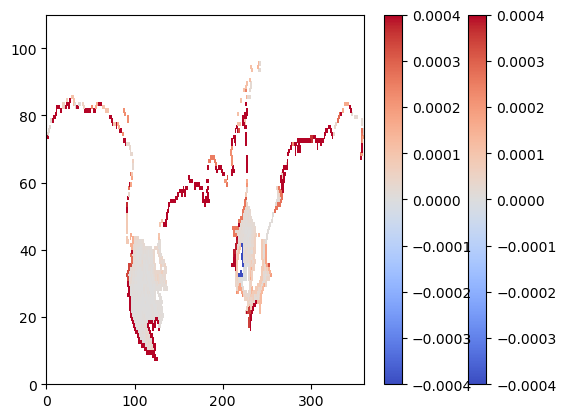

In [46]:
im = [[],[]]
im[0] = plt.pcolor(flx.sowflisf_cav.isel(time_counter = 0).values, cmap = 'coolwarm')
plt.colorbar(im[0])
plt.ylim(0,110)
im[1] = plt.pcolor(melt_all, cmap = 'coolwarm')
plt.colorbar(im[1])
for i in range(2):
    im[i].set_clim(-0.0004,0.0004)

In [47]:
flx.area

<xarray.DataArray 'area' (y: 331, x: 360)> Size: 477kB
[119160 values with dtype=float32]
Coordinates:
    nav_lat  (y, x) float32 477kB ...
    nav_lon  (y, x) float32 477kB ...
Dimensions without coordinates: y, x
Attributes:
    standard_name:  cell_area
    units:          m2

In [105]:
import glob
filepaths = glob.glob('/bettik/ockendeh/NEMO_simulations/files_copy/nn_output_melt_TOTO_*.nc')
filepaths = sorted(filepaths)

In [106]:
for i in range(len(filepaths)):
    melt = xr.open_dataset(filepaths[i])
    print(np.nansum(melt.melt))

0.441442371402187
0.014308363551109832
1.2186473432943303
-0.3435535597080149
34.326460212233464


In [107]:
filepaths2 = glob.glob('/bettik/ockendeh/NEMO_simulations/files_copy/eORCA1.L75-TOTO_1y_flxT*.nc')
filepaths2 = sorted(filepaths2)

In [129]:
for i in range(len(filepaths2)):
    melt = xr.open_dataset(filepaths[i])
    outnn = np.nansum(melt.melt * fluxes.area * (60*60*24*365.25) / 1e12)
    fluxes = xr.open_dataset(filepaths2[i])
    innemo = np.nansum(fluxes.sowflisf_par.isel(time_counter = 0) * fluxes.area * (60*60*24*365.25) / 1e12)
    #print('Melt input', np.nansum(fluxes.sowflisf_par.isel(time_counter = 0).values), '        Melt from NN', np.nansum(melt.melt))
    print('Year', i, 'In from NEMO: {:.0f}'.format(innemo))
    print('       Out from NN:  {:.0f}'.format(outnn))

Year 0 In from NEMO: 0
       Out from NN:  14090
Year 1 In from NEMO: 13270
       Out from NN:  871
Year 2 In from NEMO: 29
       Out from NN:  39621
Year 3 In from NEMO: 39142
       Out from NN:  -7583
Year 4 In from NEMO: -7950
       Out from NN:  709317


In [108]:
 #kg/m2s * m2 = kg/s * (60*60*24*365.25) = kg/yr /1e12 = Gt/yr

In [109]:
np.nansum(fluxes.sowflisf_par.isel(time_counter = 0) * fluxes.area * (60*60*24*365.25) / 1e12)

np.float32(-7949.5176)

In [110]:
melt = xr.open_dataset(filepaths[0]).melt
fluxes = xr.open_dataset(filepaths2[1]).sowflisf_par.isel(time_counter = 0)

In [111]:
flx = fluxes.values
flx[~np.isnan(flx)]

array([ 2.60606554e-04,  2.48985103e-04,  2.48985103e-04,  1.16214505e-05,
        2.48985103e-04,  1.16214505e-05,  1.16214505e-05,  1.16214505e-05,
       -1.76410629e-06, -1.76410629e-06, -1.76410629e-06,  4.38049356e-05,
       -1.76410629e-06,  4.38049356e-05, -1.76410629e-06, -1.76410629e-06,
       -1.76410629e-06,  4.38049356e-05,  4.38049356e-05,  4.38049356e-05,
        5.54785482e-04,  1.05219970e-05,  4.38049356e-05, -2.54130591e-05,
        1.13534811e-03,  5.54785482e-04,  1.05219970e-05,  4.38049356e-05,
        4.38049356e-05,  4.38049356e-05, -2.54130591e-05, -2.54130591e-05,
        1.05219970e-05, -2.54130591e-05,  1.13534811e-03,  5.54785482e-04,
       -2.54130591e-05,  1.05219970e-05,  2.01416842e-04,  1.13534811e-03,
        1.13534811e-03,  1.13534811e-03,  5.54785482e-04,  3.68466775e-04,
        1.05219970e-05, -2.54130591e-05, -2.54130591e-05,  2.01416842e-04,
        5.54785482e-04,  3.68466775e-04,  1.05219970e-05,  2.01416842e-04,
        5.54785482e-04,  

/tmp/ipykernel_2062126/1393260932.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


(0.0, 110.0)

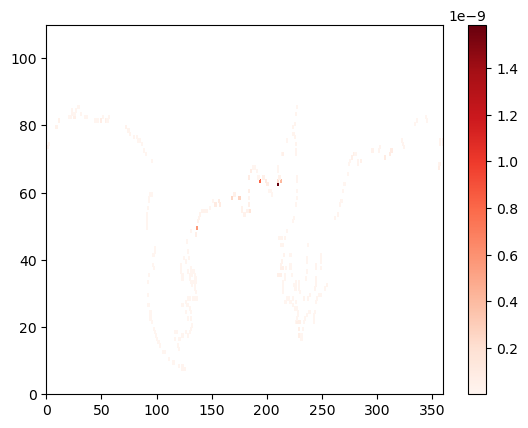

In [112]:
diff = np.abs(fluxes-melt).values
#diff[diff < 0.000001] = np.nan
plt.pcolor(np.abs(diff), cmap = 'Reds')
plt.colorbar()
plt.ylim(0,110)

0.0
13270.363
29.438293
39141.55
-7949.5176
